<a href="https://colab.research.google.com/github/jdcg5299/modelos-ai-portfolio/blob/main/Correa_Regresion_Logistica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Julian David Correa Garcia-22602198

*   Elemento de lista
*   Elemento de lista



In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
!pip install ucimlrepo
from ucimlrepo import fetch_ucirepo

# 1. Cargar el dataset desde la fuente oficial
breast_cancer_wisconsin_diagnostic = fetch_ucirepo(id=17)

# 2. Separar características (X) y objetivo (y)
X = breast_cancer_wisconsin_diagnostic.data.features
y = breast_cancer_wisconsin_diagnostic.data.targets

# 3. Crear el DataFrame con el primer grupo de 10 características (las terminadas en 1 / mean)
# Tomamos las primeras 10 columnas de X
X_primeras = X.iloc[:, 0:10]

# Unimos con el diagnóstico
dataset_analisis = pd.concat([y, X_primeras], axis=1)

# Verificamos que tenemos los 569 datos y las 11 columnas (diagnosis + 10 features)
print(f"Dataset cargado. Dimensiones: {dataset_analisis.shape}")
dataset_analisis.head(30)

Dataset cargado. Dimensiones: (569, 11)


,Diagnosis,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1
0,M,17.990,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871
1,M,20.570,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667
2,M,19.690,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999
3,M,11.420,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744
4,M,20.290,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883
5,M,12.450,15.70,82.57,477.1,0.12780,0.17000,0.15780,0.08089,0.2087,0.07613
6,M,18.250,19.98,119.60,1040.0,0.09463,0.10900,0.11270,0.07400,0.1794,0.05742
7,M,13.710,20.83,90.20,577.9,0.11890,0.16450,0.09366,0.05985,0.2196,0.07451
8,M,13.000,21.82,87.50,519.8,0.12730,0.19320,0.18590,0.09353,0.2350,0.07389
9,M,12.460,24.04,83.97,475.9,0.11860,0.23960,0.22730,0.08543,0.2030,0.08243


Los datos provienen del análisis de imágenes digitalizadas de una punción con aguja fina (PAF) de una masa mamaria. Describen las características de los núcleos celulares presentes en la muestra.
El objetivo principal es entrenar un modelo predictivo capaz de diagnosticar automáticamente si un tumor es maligno o benigno basándose únicamente en sus características geométricas.



In [ ]:
# Eliminamos la columna ID ya que es un identificador, no una característica médica
if 'id' in dataset_analisis.columns:
    dataset_analisis= dataset_analisis.drop(columns=['id'])
    # 1. Seleccionamos solo las primeras 10 columnas de X (que son las 'mean')


# 1.1 Verificar Columnas Vacías (Nulos)
print("1. BÚSQUEDA DE NULOS:")
print(dataset_analisis.isnull().sum())

# 1.2 Verificar Varianza Cero
# Si una columna tiene varianza 0, todos sus valores son iguales y no sirve para clasificar.
print("\n2. ANÁLISIS DE VARIANZA:")
varianzas = dataset_analisis.var(numeric_only=True)
print(varianzas)

# Si ves alguna variable con 0.000000, deberíamos eliminarla.


1. BÚSQUEDA DE NULOS:
Diagnosis             0
radius1               0
texture1              0
perimeter1            0
area1                 0
smoothness1           0
compactness1          0
concavity1            0
concave_points1       0
symmetry1             0
fractal_dimension1    0
dtype: int64

2. ANÁLISIS DE VARIANZA:
radius1                   12.418920
texture1                  18.498909
perimeter1               590.440480
area1                 123843.554318
smoothness1                0.000198
compactness1               0.002789
concavity1                 0.006355
concave_points1            0.001506
symmetry1                  0.000752
fractal_dimension1         0.000050
dtype: float64


Se identifica que el dataset no presenta valores nulos, esto garantiza
la integridad de la muestra, en cuanto la varianza se observa que todas las
caracteristicas poseen informacion con una varianza >0, sin embargo se debe
tener en cuenta la varianza significativa para las carateristicas de area, perimetro, smoothnes, por lo tanto estos datos al momento del entreno y testeo deben ser normalizados.

tambien convertiremos los datos de la caracteristica diagnosis en 1 y 0 para determinar su correlacion frente a las demas caracteristicas.

/tmp/ipykernel_5479/2954002652.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dataset_analisis['Diagnosis'] = dataset_analisis['Diagnosis'].replace({'M': 1, 'B': 0})


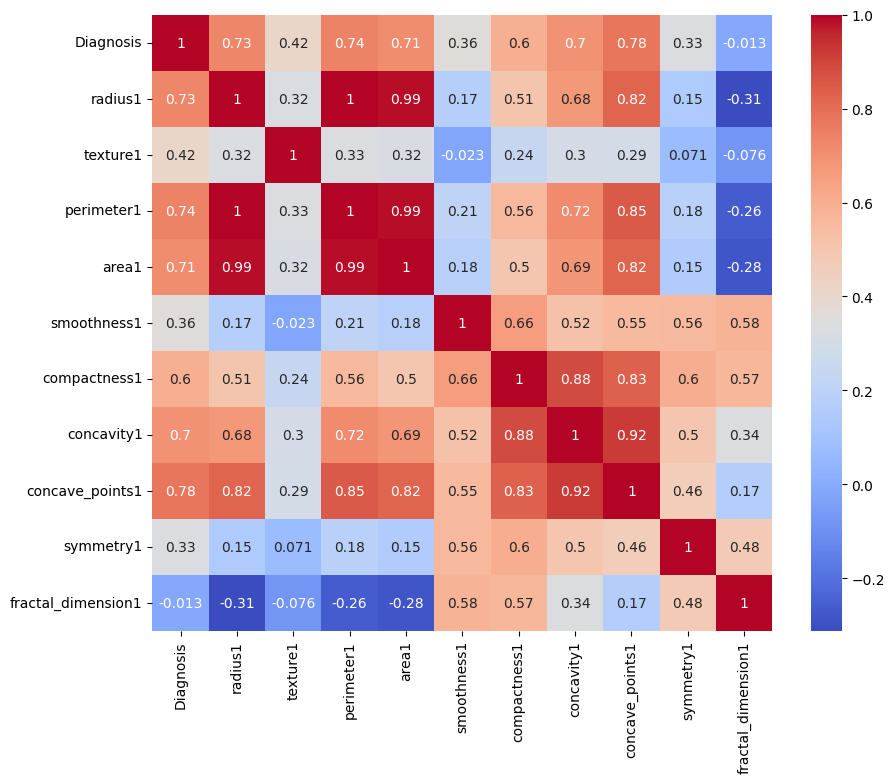

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
# 1. Convertimos la columna a números (Maligno = 1, Benigno = 0)
dataset_analisis['Diagnosis'] = dataset_analisis['Diagnosis'].replace({'M': 1, 'B': 0})



# 2. Creamos la matriz (le pedimos que solo use números para evitar errores)
matriz_corr = dataset_analisis.corr(numeric_only=True)

# 3. Graficamos
plt.figure(figsize=(10, 8))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm')
plt.show()

El proceso de selección de las variables idóneas se fundamentó en la eliminación de la redundancia multilineal, con el fin de garantizar la estabilidad numérica de la Regresión Logística y mejorar la interpretabilidad del modelo médico.
1. Eliminación por Colinealidad Perfecta caracteristica colineales =1:Se identificó que radius_mean y perimeter_mean presentaban una correlación perfecta con area_mean. En modelos lineales, esto genera una matriz singular que impide el cálculo correcto de los pesos. Se optó por conservar únicamente area_mean como la caracteristica que contiene toda la informacion del tamaño de un tumor.

2. A través de la matriz de correlación, se detectó un grupo de variables (compactness_mean, fractal_dimension_mean y smoothness_mean y simetry mean) que, aunque miden propiedades distintas, están altamente vinculadas entre sí ($r => 0.84$).Justificación: Mantener todas estas variables diluye el peso del modelo. Se eliminaron para evitar el sobre entrenamiento(overfitting), asumiendo que la información de "irregularidad de la forma" ya queda capturada por otras caracteristicas, sin embargo se mantuvo la simetria teniendo en cuenta que de las 4 caracteristicas era la que tenia mas alta correllacion con el diagnostico.

3. Priorización de Precisión Diagnóstica (concavity_mean vs concave_points_mean):A pesar de su alta correlación ($r = 0.92$), se descartó la concavidad general en favor de los puntos cóncavos. Basado en la informacion de este dataset (Wisconsin Breast Cancer), los puntos cóncavos suelen tener una correlación más directa con la variable objetivo (diagnosis), siendo un predictor más fiable de la malignidad.

con base en lo anterior pasamos de 11 caracteristicas a validar 5 consideradas dentro del analisis como las mas idoneas.

In [ ]:
variables_a_eliminar = [
    'radius1', 'perimeter1',    # Colinealidad 1.00 con Area.
    'compactness1',                 # Colinealidad masiva con todo el grupo de forma
    'concavity1',                   # Colinealidad 0.92 con Concave Points
    'fractal_dimension1',           # Baja relevancia y colineal
    'smoothness1',                  # Colineal 0.85 con el grupo

]

dataset_final = dataset_analisis.drop(columns=variables_a_eliminar)

print("Caracteristicas idóneas:")
print(dataset_final.columns.tolist())

Caracteristicas idóneas:
['Diagnosis', 'texture1', 'area1', 'concave_points1', 'symmetry1']


In [ ]:
from sklearn.model_selection import train_test_split

# 1. Separamos la variable objetivo (y) de las variables predictoras (X)
X = dataset_final.drop(columns=['Diagnosis']) # Todas menos Diagnosis
y = dataset_final['Diagnosis']                # Solo la etiqueta (M o B)

# 2. Dividimos el dataset: 80% para entrenar y 20% para evaluar
# random_state=42 asegura que si corres el código de nuevo, obtengas la misma división
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Total de datos: {len(dataset_final)}")
print(f"Datos para entrenamiento (X_train): {len(X_train)}")
print(f"Datos para prueba (X_test): {len(X_test)}")

Total de datos: 569
Datos para entrenamiento (X_train): 455
Datos para prueba (X_test): 114


In [ ]:
# Normalizar.

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# 1. Escalar los datos (basado en lo que aprendimos antes)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
#Crear y entrenar la Regresión Logística
modelo = LogisticRegression()
modelo.fit(X_train_scaled, y_train)

#Predicción y Resultado
predicciones = modelo.predict(X_test_scaled)
precision = accuracy_score(y_test, predicciones)

print(f"Resultado del examen (Precisión): {precision * 100}%")
print(f"Predicciones del modelo: {predicciones}")
print(f"Valores reales (y_test):  {y_test.values}")



Resultado del examen (Precisión): 95.6140350877193%
Predicciones del modelo: [0 1 1 0 0 1 1 1 0 0 0 1 0 1 0 1 0 0 0 1 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0
 0 1 0 0 1 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 1 0 0 0 1 1 0 0 0 1 1 0 0 1 1 0 1
 0 0 0 0 0 0 1 0 1 1 1 1 1 1 0 0 0 0 0 0 0 0 1 1 0 1 1 0 1 1 0 0 0 1 0 0 1
 0 1 1]
Valores reales (y_test):  [0 1 1 0 0 1 1 1 0 0 0 1 0 1 0 1 0 0 0 1 1 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 1
 0 1 0 0 1 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 1 1 0 0 1 1 0 0 0 1 1 0 0 1 1 0 1
 0 0 0 1 0 0 1 0 1 1 1 1 1 1 0 0 0 0 0 0 0 0 1 1 0 1 1 0 1 1 0 0 0 1 0 0 1
 0 0 1]



--- Reporte de Clasificación ---
              precision    recall  f1-score   support

 Benigno (B)       0.95      0.99      0.97        71
 Maligno (M)       0.97      0.91      0.94        43

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



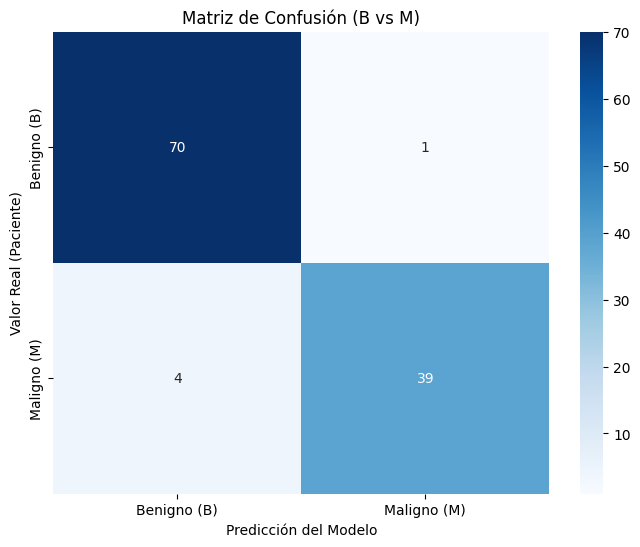

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix



# 1. Ver el reporte detallado (Éxito por categoría)
print("\n--- Reporte de Clasificación ---")
print(classification_report(y_test, predicciones, target_names=['Benigno (B)', 'Maligno (M)']))


MC = confusion_matrix(y_test, predicciones)

# 2. Definimos las etiquetas en el orden correcto (0 es B, 1 es M)
etiquetas = ['Benigno (B)', 'Maligno (M)']

# 3. Graficamos
plt.figure(figsize=(8, 6))
sns.heatmap(MC,
            annot=True,           # Pone los números dentro de los cuadros
            fmt='d',              # Formato de número entero
            cmap='Blues',         # Color azul
            xticklabels=etiquetas, # Etiquetas para el eje X (Predicciones)
            yticklabels=etiquetas) # Etiquetas para el eje Y (Valores Reales)

plt.xlabel('Predicción del Modelo')
plt.ylabel('Valor Real (Paciente)')
plt.title('Matriz de Confusión (B vs M)')
plt.show()

El modelo presenta un desempeño sobresaliente con una exactitud global del 96%. No obstante, desde una perspectiva de gestión de riesgos, el indicador crítico es el recall de tumores malignos (91%).

Actualmente, el sistema genera un 4% de falsos negativos (4 pacientes con tumores malignos clasificados erróneamente como benignos). Dado que el costo de omisión en estos casos es crítico para la salud del paciente, el modelo no puede operar de forma autónoma. Se recomienda su implementación como una herramienta de apoyo al diagnóstico, manteniendo una validación humana obligatoria en todos los casos clasificados como benignos para mitigar el riesgo clínico.

Precisión de Naive Bayes: 92.98%
--- REPORTE DE CLASIFICACIÓN: NAIVE BAYES ---
              precision    recall  f1-score   support

 Benigno (B)       0.93      0.96      0.94        71
 Maligno (M)       0.93      0.88      0.90        43

    accuracy                           0.93       114
   macro avg       0.93      0.92      0.92       114
weighted avg       0.93      0.93      0.93       114



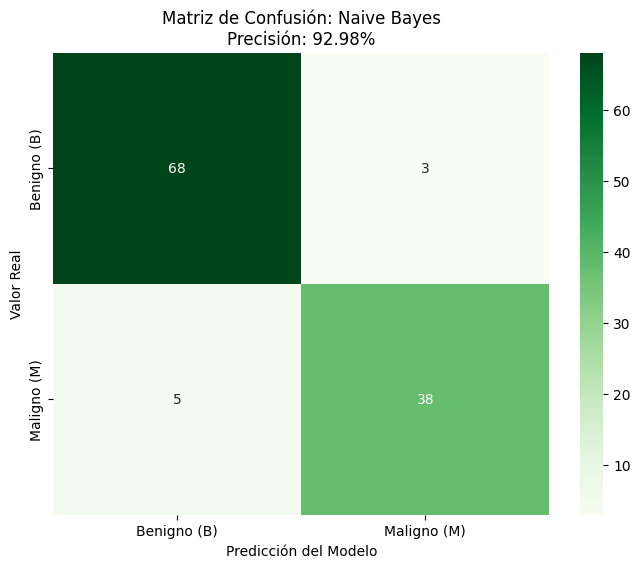

In [ ]:
# Crear y entrenar bajo naive bayes

from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Crear el modelo Naive Bayes
modelo_nb = GaussianNB()

# 2. Entrenar el modelo (usamos los mismos datos escalados que en la Regresión Logística)
modelo_nb.fit(X_train_scaled, y_train)

# 3. Realizar predicciones
predicciones_nb = modelo_nb.predict(X_test_scaled)

# 4. Calcular precisión
precision_nb = accuracy_score(y_test, predicciones_nb)

print(f"Precisión de Naive Bayes: {precision_nb * 100:.2f}%")

#Reporte de clasificacion
reporte_nb = classification_report(y_test, predicciones_nb, target_names=['Benigno (B)', 'Maligno (M)'])

print("--- REPORTE DE CLASIFICACIÓN: NAIVE BAYES ---")
print(reporte_nb)
plt.show()


#  Calcular matriz
cm_nb = confusion_matrix(y_test, predicciones_nb)

# Graficar
plt.figure(figsize=(8, 6))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Benigno (B)', 'Maligno (M)'],
            yticklabels=['Benigno (B)', 'Maligno (M)'])

plt.title(f'Matriz de Confusión: Naive Bayes\nPrecisión: {precision_nb*100:.2f}%')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Valor Real')
plt.show()


El modelo presenta un desempeño un poco mas bajo con una exactitud global del 93%., generando asi una alerta, en temas de medicina el indicador debe ser lo mas preciso posible, aunque es aceptable considero que no es fiable debido a que el indicador crítico es el recall de tumores malignos (88%).

Actualmente, el sistema genera un dato de 5 falsos negativos ( pacientes con tumores malignos clasificados erróneamente como benignos). Dado que el costo de omisión en estos casos es crítico para la salud del paciente, el modelo no puede operar de forma autónoma. Se recomienda su implementación como una herramienta de apoyo al diagnóstico, manteniendo una validación humana obligatoria en todos los casos clasificados como benignos para mitigar el riesgo clínico.

hasta este punto el modelo mas confiable seria el de Regresion Logistica.



Precisión de KNN: 96.49%

--- REPORTE DE CLASIFICACIÓN: KNN ---
              precision    recall  f1-score   support

 Benigno (B)       0.96      0.99      0.97        71
 Maligno (M)       0.98      0.93      0.95        43

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



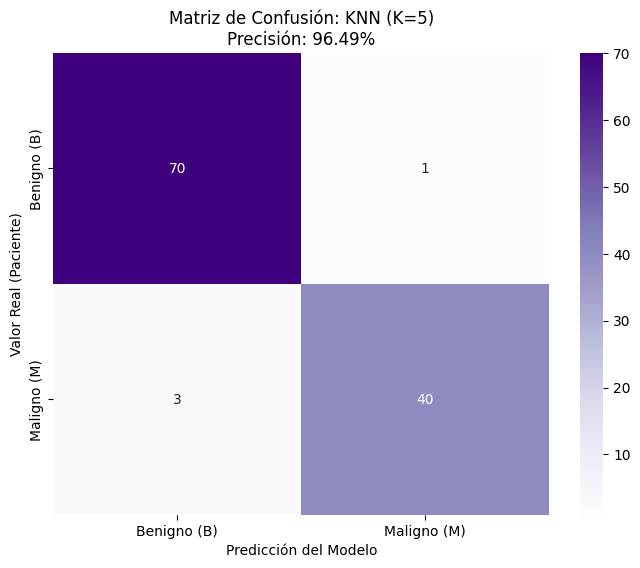

In [ ]:
# Modelo investigado KNN
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Crear el modelo KNN (usaremos K=5 vecinos)
modelo_knn = KNeighborsClassifier(n_neighbors=10)

# 2. Entrenar el modelo
modelo_knn.fit(X_train_scaled, y_train)

# 3. Predicciones
predicciones_knn = modelo_knn.predict(X_test_scaled)

# 4. Evaluación
precision_knn = accuracy_score(y_test, predicciones_knn)

print(f"Precisión de KNN: {precision_knn * 100:.2f}%")
print("\n--- REPORTE DE CLASIFICACIÓN: KNN ---")
print(classification_report(y_test, predicciones_knn, target_names=['Benigno (B)', 'Maligno (M)']))

# Calcular la matriz de confusión para KNN
cm_knn = confusion_matrix(y_test, predicciones_knn)

#Configurar el estilo y graficar
plt.figure(figsize=(8, 6))
sns.heatmap(cm_knn,
            annot=True,           # Mostrar los números
            fmt='d',              # Formato de números enteros
            cmap='Purples',       # Color distintivo para KNN
            xticklabels=['Benigno (B)', 'Maligno (M)'],
            yticklabels=['Benigno (B)', 'Maligno (M)'])

plt.title(f'Matriz de Confusión: KNN (K=5)\nPrecisión: {precision_knn*100:.2f}%')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Valor Real (Paciente)')
plt.show()


Se realiza la validacion del dataset entrenando un modelo bajo el algoritmo KNN, el cual es un modelo basado en su similitud, donde se le indica cuantos "vecinos", es decir otros pacientes con sus carateristicas tiene a su alredeodr y estan mas proximos a el, si esos vecinos son calificados como malignos, probablemente el dato del modelo tambien lo sea.

es un modelo sencillo y puede ser utilizado en datos no lineales, pero es un algoritmo perezosos puesto no que no realiza entrenamiento, solamente guarda todos los datos y el trabajo lo realiza en el testeo de la forma indicada.

In [ ]:
from sklearn.metrics import roc_auc_score

# Calculamos el AUC para cada modelo
auc_log = roc_auc_score(y_test, predicciones)
auc_nb = roc_auc_score(y_test, predicciones_nb)
auc_knn = roc_auc_score(y_test, predicciones_knn)

# Creamos una tabla comparativa
comparativa = pd.DataFrame({
    'Modelo': ['Regresión Logística', 'Naive Bayes', 'KNN'],
    'Accuracy': [precision, precision_nb, precision_knn],
    'AUC Score (Índice Adicional)': [auc_log, auc_nb, auc_knn]
})

print("--- TABLA COMPARATIVA DE MODELOS ---")
print(comparativa)

--- TABLA COMPARATIVA DE MODELOS ---
                Modelo  Accuracy  AUC Score (Índice Adicional)
0  Regresión Logística  0.956140                      0.946446
1          Naive Bayes  0.929825                      0.920734
2                  KNN  0.964912                      0.958074


Se utiliza otro indicador para comparar los tres modelos a parte de las matrices de confusiones, este es el AUC que mide el area bajo la curva el cual nos brinda la capacidad del modelo para distinguir entre clases, Aunque el modelo KNN obtuvo el Accuracy (exactitud) y AUC más altos, se considera que la Regresión Logística es más idónea para la implementación clínica. Esto se debe a que la Regresión Logística ofrece explicabilidad a través de sus coeficientes, se podrian conocer que pesos tiene caracteristica y cual pesa mas en el diagnostico, basandonos en la data de forma mas especifica y no solamente por lo que se tiene alrededor, eso asi permitiendo al personal médico entender qué variables influyen en el diagnóstico, a diferencia del KNN que es un modelo basado únicamente en proximidad geométrica."